
#PedalEase: Converting Casual Riders into Loyal Annual Members

#Introduction

 ### Business Problem
- PedalEase needs to increase recurring revenue by converting casual riders to annual members.

- Casual riders represent a large share of trips but low lifetime value and unpredictable revenue.

- Lack of detailed understanding of the differences in ride behaviors between casual and member riders hinders effective targeted marketing.

### Objective
- Analyze last 12 months of ride data to uncover differences in riding patterns, preferences, and behaviors between casual and member riders.

- Identify high-potential casual riders for membership conversion.

- Use insights to design targeted campaigns that improve annual membership conversion rates.

### Business Impact
- Increasing membership conversions will lead to higher customer retention, predictable revenue streams, and enhanced profitability.

 - Tailored marketing reduces wasted spend and improves ROI by focusing on riders with the highest likelihood to convert.

- Understanding usage patterns supports service improvements, station placements, and product bundle offerings aligned with rider needs.



#Data Overview

### Importing Necessary Libraries

In [ ]:
import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical computations
import matplotlib.pyplot as plt  # For plotting and visualization
import seaborn as sns  # For advanced visualizations

### Loading Dataset from the Google drive

In [ ]:
# Step 1: Install gdown
!pip install gdown

# Step 2: Import below libraries
import gdown

# Step 3: Set the file ID and create a download URL
# E.g. for pedalease_data.csv the URL is  --https://drive.google.com/file/d/1KxvbVTcMW0YaK5tael8Klyi9o2AxEe-K/view?usp=sharing

file_id = "1KxvbVTcMW0YaK5tael8Klyi9o2AxEe-K"
download_url = f"https://drive.google.com/uc?id={file_id}"

# Step 4: Set the output file name
output_file = "pedalease_data.csv"

# Step 5: Download the file
gdown.download(download_url, output_file, quiet=False)

# Step 6: Load the CSV file into a Pandas DataFrame (change name according to your choice)
pe_data = pd.read_csv(output_file)



Downloading...
From (original): https://drive.google.com/uc?id=1KxvbVTcMW0YaK5tael8Klyi9o2AxEe-K
From (redirected): https://drive.google.com/uc?id=1KxvbVTcMW0YaK5tael8Klyi9o2AxEe-K&confirm=t&uuid=45e49b18-8386-44f3-b3bd-724ff502fe1d
To: /content/pedalease_data.csv
100%|██████████| 1.07G/1.07G [00:25<00:00, 41.0MB/s]
/tmp/ipython-input-1814941355.py:20: DtypeWarning: Columns (13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  pe_data = pd.read_csv(output_file)


###Viewing First few rows of the dataset

In [ ]:
# Viewing First five rows of the dataset
print("First 5 Rows of the Dataset:")
print(pe_data.head())


First 5 Rows of the Dataset:
            ride_id  rideable_type member_casual  Start_day_of_the_week  \
0  6325229942E058A1   classic_bike        casual                      3   
1  E7F30D46ACF9071D  electric_bike        casual                      3   
2  C998184FE3DD7937   classic_bike        casual                      3   
3  CD92D9AF505AA077   classic_bike        casual                      3   
4  F4BC162A9AA95610  electric_bike        casual                      3   

         started_at          ended_at Ride_length  \
0  01-02-2022 00:03  01-02-2022 00:09    00:06:19   
1  01-02-2022 00:04  01-02-2022 00:17    00:12:42   
2  01-02-2022 00:08  01-02-2022 00:47    00:39:59   
3  01-02-2022 00:08  01-02-2022 00:47    00:39:51   
4  01-02-2022 00:50  01-02-2022 00:55    00:05:10   

                      start_station_name start_station_id  \
0  DuSable Lake Shore Dr & Diversey Pkwy     TA1309000039   
1                  Broadway & Berwyn Ave            13109   
2                 

### Checking the Shape of the Dataset

In [ ]:
rows,columns = pe_data.shape
print(f"The dataset has {rows} rows and {columns} columns")

The dataset has 5754248 rows and 15 columns


### Column Headers

In [ ]:
print("Dataset Columns:", pe_data.columns)

Dataset Columns: Index(['ride_id', 'rideable_type', 'member_casual', 'Start_day_of_the_week',
       'started_at', 'ended_at', 'Ride_length', 'start_station_name',
       'start_station_id', 'end_station_name', 'end_station_id', 'start_lat',
       'start_lng', 'end_lat', 'end_lng'],
      dtype='object')


### Displaying dataset Information

In [ ]:
print(f"Displaying dataset information")
pe_data.info()


Displaying dataset information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5754248 entries, 0 to 5754247
Data columns (total 15 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ride_id                object 
 1   rideable_type          object 
 2   member_casual          object 
 3   Start_day_of_the_week  int64  
 4   started_at             object 
 5   ended_at               object 
 6   Ride_length            object 
 7   start_station_name     object 
 8   start_station_id       object 
 9   end_station_name       object 
 10  end_station_id         object 
 11  start_lat              float64
 12  start_lng              float64
 13  end_lat                object 
 14  end_lng                object 
dtypes: float64(2), int64(1), object(12)
memory usage: 658.5+ MB


### Changing Data types

In [ ]:
pe_data['end_lng'] = pd.to_numeric(pe_data['end_lng'], errors='coerce')
pe_data['end_lat'] = pd.to_numeric(pe_data['end_lat'], errors='coerce')
print(f"Displaying dataset information")
pe_data.info()


Displaying dataset information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5754248 entries, 0 to 5754247
Data columns (total 15 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ride_id                object 
 1   rideable_type          object 
 2   member_casual          object 
 3   Start_day_of_the_week  int64  
 4   started_at             object 
 5   ended_at               object 
 6   Ride_length            object 
 7   start_station_name     object 
 8   start_station_id       object 
 9   end_station_name       object 
 10  end_station_id         object 
 11  start_lat              float64
 12  start_lng              float64
 13  end_lat                float64
 14  end_lng                float64
dtypes: float64(4), int64(1), object(10)
memory usage: 658.5+ MB


### Checking for Duplicates

In [ ]:
duplicate_count= len(pe_data[pe_data.duplicated()])
print(f"Number of Duplicate rows of the follwing datset is {duplicate_count}")

Number of Duplicate rows of the follwing datset is 0


### Checking for null values

In [ ]:
missing_values= pe_data.isnull().sum()
print(f"\nMissing rows in the dataset:")
print(missing_values)


Missing rows in the dataset:
ride_id                     0
rideable_type               0
member_casual               0
Start_day_of_the_week       0
started_at                  0
ended_at                    0
Ride_length               100
start_station_name          0
start_station_id            0
end_station_name            0
end_station_id              0
start_lat                   0
start_lng                   0
end_lat                  5899
end_lng                  5899
dtype: int64


### Column Definitions

In [ ]:
print("\n### Variables Description ###")
variable_descriptions = {
"ride_id" : "Unique identifier for each bike trip, applicable to both members and casual riders.",
"rideable_type" : 'Type of bike used for the ride. Can be one of categories: classic, docked, electric, etc."',
"member_casual" : "Indicates whether the rider is an annual member or a casual (non-member) rider.",
"start_day_of_week" : "Day of the week on which the trip started.",

"started_at" : "Date and time the trip started in YYYY-MM-DD HH:MM:SS format.",

"ended_at" : "Date and time the trip ended in YYYY-MM-DD HH:MM:SS format.",

  "ride_length" : "Duration of the ride in hours, minutes, and seconds.",

"start_station_name" :"Name of the station where the bike was picked up.",

"start_station_id" : "Unique identifier for the station where the bike was picked up.",

"end_station_name" : "Name of the station where the bike was returned.",

"end_station_id" : "Unique identifier for the station where the bike was returned.",

"start_lat": "Latitude coordinate of the station where the bike was picked up.",

"start_lng": "Longitude coordinate of the station where the bike was picked up.",

"end_lat ": "Latitude coordinate of the station where the bike was returned.",

"end_lng" : "Longitude coordinate of the station where the bike was returned."
}

for col, desc in variable_descriptions.items():
    print(f"* **{col}**: {desc}")


### Variables Description ###
* **ride_id**: Unique identifier for each bike trip, applicable to both members and casual riders.
* **rideable_type**: Type of bike used for the ride. Can be one of categories: classic, docked, electric, etc."
* **member_casual**: Indicates whether the rider is an annual member or a casual (non-member) rider.
* **start_day_of_week**: Day of the week on which the trip started.
* **started_at**: Date and time the trip started in YYYY-MM-DD HH:MM:SS format.
* **ended_at**: Date and time the trip ended in YYYY-MM-DD HH:MM:SS format.
* **ride_length**: Duration of the ride in hours, minutes, and seconds.
* **start_station_name**: Name of the station where the bike was picked up.
* **start_station_id**: Unique identifier for the station where the bike was picked up.
* **end_station_name**: Name of the station where the bike was returned.
* **end_station_id**: Unique identifier for the station where the bike was returned.
* **start_lat**: Latitude coordinate of

### Unknown start and end stations


In [ ]:
count_start_station_is_0 = ((pe_data['start_station_id'] == '0')&(pe_data['end_station_id'] != '0')).sum()
count_end_station_is_0 =((pe_data['start_station_id'] != '0')&(pe_data['end_station_id'] == '0')).sum()
count_both_stations_0 = ((pe_data['start_station_id'] == '0') & (pe_data['end_station_id']=='0')).sum()
print(f"Number of of entries missing the start stations only is {count_start_station_is_0}")
print(f"Number of of entries missing the end stations only is {count_end_station_is_0}")
print(f"Number of of entries missing the start and end stations is {count_both_stations_0}")


Number of of entries missing the start stations only is 414077
Number of of entries missing the end stations only is 473207
Number of of entries missing the start and end stations is 429448


### Ride length in seconds

In [ ]:
# Converting hh:mm:ss to seconds for ease in analysis
pe_data['ride_length_seconds'] = pd.to_timedelta(pe_data['Ride_length']).dt.total_seconds()

### Unique Values for each column

In [ ]:
# Unique Values for Each Variable
print("\n Unique Values for Each Variable")
for column in pe_data.columns.tolist():
    print(f"No. of unique values in {column}: {pe_data[column].nunique()}.")


 Unique Values for Each Variable
No. of unique values in ride_id: 5754027.
No. of unique values in rideable_type: 3.
No. of unique values in member_casual: 2.
No. of unique values in Start_day_of_the_week: 7.
No. of unique values in started_at: 461149.
No. of unique values in ended_at: 461894.
No. of unique values in Ride_length: 21774.
No. of unique values in start_station_name: 8681.
No. of unique values in start_station_id: 2524.
No. of unique values in end_station_name: 8792.
No. of unique values in end_station_id: 2527.
No. of unique values in start_lat: 44.
No. of unique values in start_lng: 33.
No. of unique values in end_lat: 60.
No. of unique values in end_lng: 46.
No. of unique values in ride_length_seconds: 21774.


# Data Wrangling and Visualization


In [ ]:
# Copying dataset for analysis
df = pe_data.copy()

### a. Ride length difference between casual and members

In [ ]:
grouped_stats = df.groupby('member_casual')['ride_length_seconds'].agg(['mean', 'median', 'count']).reset_index()
# Calculate percentage of total rides for each rider group
total_rides = grouped_stats['count'].sum()
grouped_stats['percentage'] = (grouped_stats['count'] / total_rides * 100).round(2)
print(grouped_stats)

  member_casual         mean  median    count  percentage
0        casual  1334.896195   775.0  2343465       40.73
1        member   739.354196   526.0  3410683       59.27


### b. Ride Frequency

In [ ]:
# Calculate rides per user grouped by member_casual
rides_per_user = df.groupby(['member_casual', 'ride_id']).size().reset_index(name='ride_count')

# Summarize statistics of ride_count by rider type
summary_stats = rides_per_user.groupby('member_casual')['ride_count'].agg(['mean', 'median', 'count']).reset_index()
print(summary_stats)


  member_casual      mean  median    count
0        casual  1.000014     1.0  2343487
1        member  1.000026     1.0  3410639


In [ ]:
# Identify ride_ids with duplicates
duplicate_ride_ids = df['ride_id'].value_counts()
duplicate_ride_ids = duplicate_ride_ids[duplicate_ride_ids > 1].index

# Filter rows with duplicate ride_ids
duplicates_df = df[df['ride_id'].isin(duplicate_ride_ids)]

# Count number of duplicates by member_casual
duplicate_counts_by_group = duplicates_df['member_casual'].value_counts()
print(f"Repeated Rides")
print(duplicate_counts_by_group)


Repeated Rides
member_casual
member    270
casual    164
Name: count, dtype: int64


### c. Riderable type by rider group

In [ ]:
# Calculate counts of each rideable_type within each rider group
usage_counts = pd.crosstab(df['member_casual'], df['rideable_type'])

# Calculate percentage share of each bike type within each rider group
usage_percent = usage_counts.div(usage_counts.sum(axis=1), axis=0) * 100

print("Rideable Type Counts by Rider Group:")
print(usage_counts)
print("\nRideable Type Percentage Share by Rider Group:")
print(usage_percent.round(2))

Rideable Type Counts by Rider Group:
rideable_type  classic_bike  docked_bike  electric_bike
member_casual                                          
casual               898394       178251        1266875
member              1738047            0        1672681

Rideable Type Percentage Share by Rider Group:
rideable_type  classic_bike  docked_bike  electric_bike
member_casual                                          
casual                38.34         7.61          54.06
member                50.96         0.00          49.04


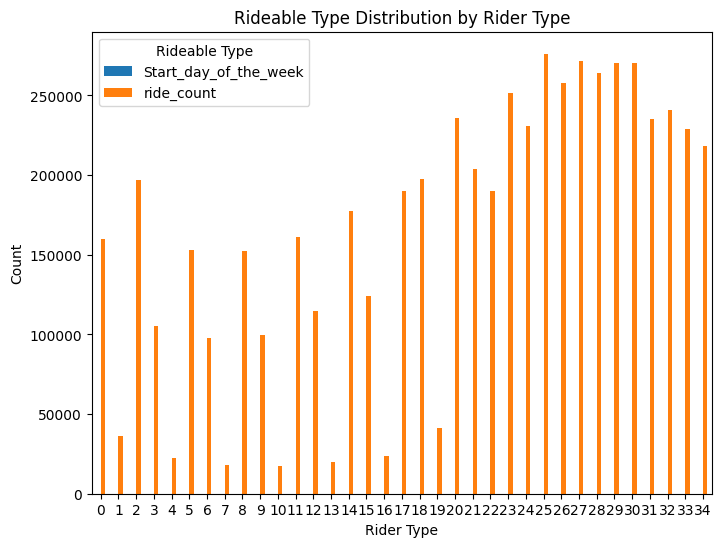

In [ ]:
# Visualization - Bar chart of counts
usage_counts.plot(kind='bar', stacked=False, figsize=(8,6))
plt.title('Rideable Type Distribution by Rider Type')
plt.ylabel('Count')
plt.xlabel('Rider Type')
plt.xticks(rotation=0)
plt.legend(title='Rideable Type')
plt.show()

### d. Maximum usage day


In [ ]:
# Ensure started_at is datetime with dayfirst=True
df['started_at'] = pd.to_datetime(df['started_at'], dayfirst=True)

# Extract hour of day from started_at
df['start_hour'] = df['started_at'].dt.hour

# Pivot table: count of rides by day of week and member_casual
pivot_day = df.pivot_table(index='Start_day_of_the_week',
                           columns='member_casual',
                           values='ride_id', aggfunc='count', fill_value=0)
print("Rides by Day of Week and Rider Type:")
print(pivot_day)

# Pivot table: count of rides by hour of day and member_casual
pivot_hour = df.pivot_table(index='start_hour',
                            columns='member_casual',
                            values='ride_id', aggfunc='count', fill_value=0)
print("\nRides by Hour of Day and Rider Type:")
print(pivot_hour)


Rides by Day of Week and Rider Type:
member_casual          casual  member
Start_day_of_the_week                
1                      392898  394218
2                      280944  482614
3                      268256  534248
4                      277943  535827
5                      311809  540895
6                      337254  475843
7                      474416  447083

Rides by Hour of Day and Rider Type:
member_casual  casual  member
start_hour                   
0               46769   36761
1               30340   22560
2               18790   13165
3               11149    8152
4                7728    9070
5               12633   32667
6               30097   93581
7               52599  176768
8               71030  210663
9               73096  147653
10              93768  138630
11             122464  165358
12             145288  190884
13             151635  189347
14             161379  188044
15             179857  225631
16             199880  297524
17           

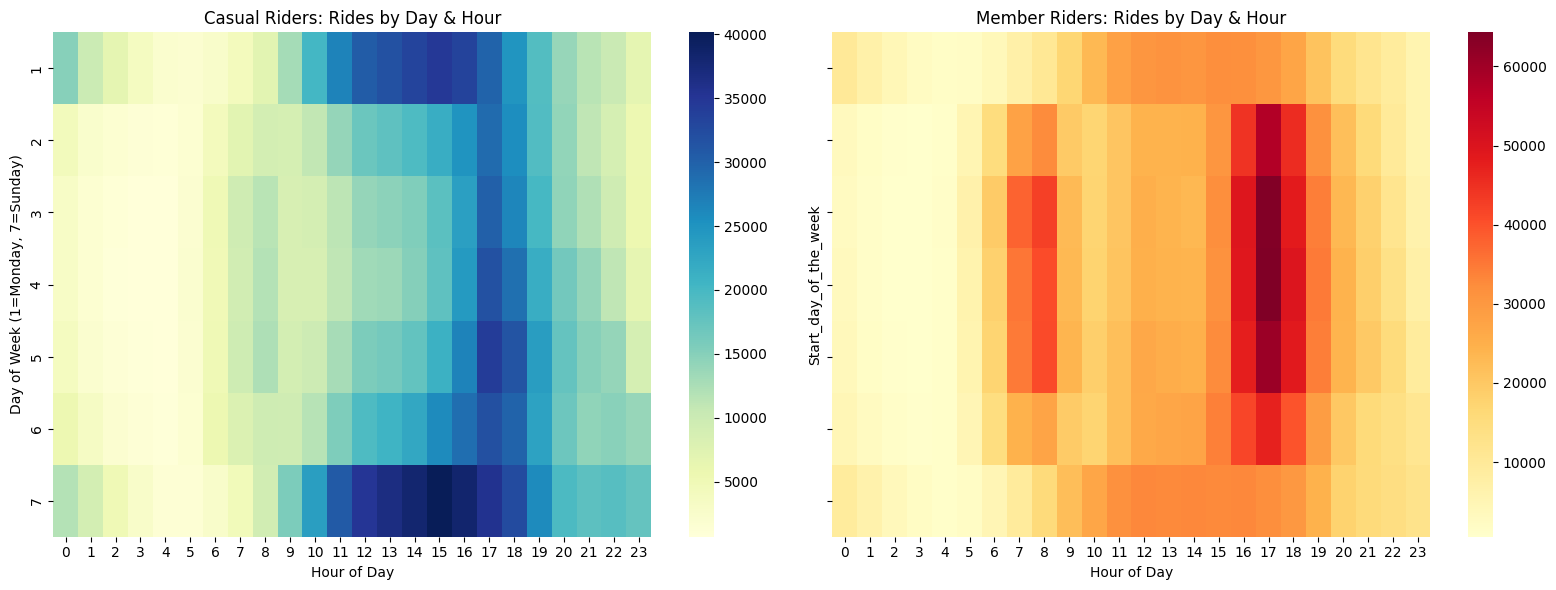

In [ ]:
# Make sure started_at is datetime
df['started_at'] = pd.to_datetime(df['started_at'])

# Extract hour of day from started_at
df['start_hour'] = df['started_at'].dt.hour

# Create pivot table: counts of rides grouped by day of week, hour, and member_casual
pivot = df.pivot_table(index='Start_day_of_the_week', columns=['start_hour', 'member_casual'],
                       values='ride_id', aggfunc='count', fill_value=0)

# Separate data for casual and member riders
casual_heatmap = pivot.xs('casual', level=1, axis=1)
member_heatmap = pivot.xs('member', level=1, axis=1)

# Plot heatmaps side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

sns.heatmap(casual_heatmap, cmap='YlGnBu', ax=axes[0])
axes[0].set_title('Casual Riders: Rides by Day & Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Day of Week (1=Monday, 7=Sunday)')

sns.heatmap(member_heatmap, cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Member Riders: Rides by Day & Hour')
axes[1].set_xlabel('Hour of Day')

plt.tight_layout()
plt.show()


### e. Favourite start & end station


In [ ]:
# Remove invalid station names from the dataset first
valid_df = df[~df['start_station_name'].isin(['Unknown_Start_station_name', 'ride_id','member'])]

# Popular start stations by rider segment using filtered data
start_station_popularity = valid_df.groupby(['member_casual', 'start_station_name']).size().reset_index(name='ride_count')
start_station_popularity_sorted = start_station_popularity.sort_values(['member_casual', 'ride_count'], ascending=[True, False])

print("Top 10 Start Stations for Each Rider Segment:")
for segment in start_station_popularity_sorted['member_casual'].unique():
    print(f"\nRider Segment: {segment}")
    print(start_station_popularity_sorted[start_station_popularity_sorted['member_casual'] == segment].head(10).to_string(index=False))


# Remove invalid end station names similarly
valid_df_end = df[~df['end_station_name'].isin(['Unknown_End_Station_name', 'member','ride_id'])]

# Popular end stations by rider segment using filtered data
end_station_popularity = valid_df_end.groupby(['member_casual', 'end_station_name']).size().reset_index(name='ride_count')
end_station_popularity_sorted = end_station_popularity.sort_values(['member_casual', 'ride_count'], ascending=[True, False])

print("\nTop 10 End Stations for Each Rider Segment:")
for segment in end_station_popularity_sorted['member_casual'].unique():
    print(f"\nRider Segment: {segment}")
    print(end_station_popularity_sorted[end_station_popularity_sorted['member_casual'] == segment].head(10).to_string(index=False))



Top 10 Start Stations for Each Rider Segment:

Rider Segment: casual
member_casual      start_station_name  ride_count
       casual        CD9C9FCF401F00C2       11794
       casual        FAE58644F2699AAC        9651
       casual        F5094539E39BDA4C        9608
       casual        BFA8589DDC179A2F        7743
       casual        893AD1EAA630AABB        7016
       casual        BD3386DB7929ACE3        6154
       casual Streeter Dr & Grand Ave        5722
       casual        2506DC75195A100C        5574
       casual        1350F71B4E6D5024        5508
       casual        E19EE2F09910A1A0        5127

Rider Segment: member
member_casual           start_station_name  ride_count
       member     University Ave & 57th St        6261
       member          Ellis Ave & 60th St        5249
       member     Kingsbury St & Kinzie St        5042
       member Clinton St & Washington Blvd        4575
       member Michigan Ave & Washington St        4430
       member     Wilton Ave

### f. Monthly trends by rider type

In [ ]:
# Monthly aggregates by rider type
df['started_at'] = pd.to_datetime(df['started_at'], dayfirst=True)
df['year_month'] = df['started_at'].dt.to_period('M')

monthly_stats = df.groupby(['year_month', 'member_casual']).agg(
    ride_count=('ride_id', 'count'),
    total_ridelength=('ride_length_seconds', 'sum'),
    average_ridelength=('ride_length_seconds', 'mean')
).reset_index()

print(monthly_stats)


   year_month member_casual  ride_count  total_ridelength  average_ridelength
0     2022-02        casual       21416        26111291.0         1219.242202
1     2022-02        member       94193        62385662.0          662.317391
2     2022-03        casual       89882       134112705.0         1492.130674
3     2022-03        member      194160       136285748.0          701.924948
4     2022-04        casual      126417       179853650.0         1422.701456
5     2022-04        member      244832       166576097.0          680.368975
6     2022-05        casual      280415       435397342.0         1552.694737
7     2022-05        member      354443       277697103.0          783.474643
8     2022-06        casual      369051       529934913.0         1435.966749
9     2022-06        member      400153       327812361.0          819.227788
10    2022-07        casual      406055       574123085.0         1413.936069
11    2022-07        member      417433       336419913.0       

### g. Average geographical distance covered by casual and members

In [ ]:

# Haversine formula to calculate distance in kilometers
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Radius of earth in kilometers
    lat1, lon1, lat2, lon2 = np.deg2rad([lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# Calculate haversine distance for each ride
df['distance_km'] = haversine(df['start_lat'], df['start_lng'], df['end_lat'], df['end_lng'])

# Group by member_casual for descriptive statistics
distance_stats = df.groupby('member_casual')['distance_km'].agg(['mean', 'median', 'max', 'min', 'count']).reset_index()
print(distance_stats)


  member_casual      mean    median          max  min    count
0        casual  2.187464  1.654755  9813.748840  0.0  2338305
1        member  2.118844  1.386421  9813.012193  0.0  3410044


In [ ]:
import numpy as np

# Calculate differences in latitudes and longitudes
df['lat_diff'] = df['start_lat'] - df['end_lat']
df['lng_diff'] = df['start_lng'] - df['end_lng']

# Approximate conversion: 1 degree latitude ≈ 111 km
# Adjust longitude scaling by multiplying with cosine of latitude (average of start and end latitudes)
avg_lat_rad = np.deg2rad((df['start_lat'] + df['end_lat']) / 2)
df['distance_km_approx'] = np.sqrt(
    (df['lat_diff'] * 111) ** 2 +
    (df['lng_diff'] * 111 * np.cos(avg_lat_rad)) ** 2
)

# Group by rider type and calculate summary statistics for distance
distance_stats = df.groupby('member_casual')['distance_km_approx'].agg(['mean', 'median', 'max', 'min', 'count']).reset_index()

print(distance_stats)


  member_casual      mean    median           max  min    count
0        casual  2.183980  1.651854  10206.898705  0.0  2338305
1        member  2.115853  1.383991  10206.681499  0.0  3410044


### h. Bike Type weekly stats

   member_casual  Start_day_of_the_week  rideable_type  ride_count
0         casual                      1   classic_bike      159954
1         casual                      1    docked_bike       35962
2         casual                      1  electric_bike      196982
3         casual                      2   classic_bike      105286
4         casual                      2    docked_bike       22724
5         casual                      2  electric_bike      152934
6         casual                      3   classic_bike       97724
7         casual                      3    docked_bike       17903
8         casual                      3  electric_bike      152629
9         casual                      4   classic_bike       99597
10        casual                      4    docked_bike       17418
11        casual                      4  electric_bike      160928
12        casual                      5   classic_bike      114525
13        casual                      5    docked_bike       1

/tmp/ipython-input-1049268066.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=usage_counts, x='Start_day_of_the_week', y='ride_count', hue='rideable_type', ci=None, palette='Set2', estimator=sum)


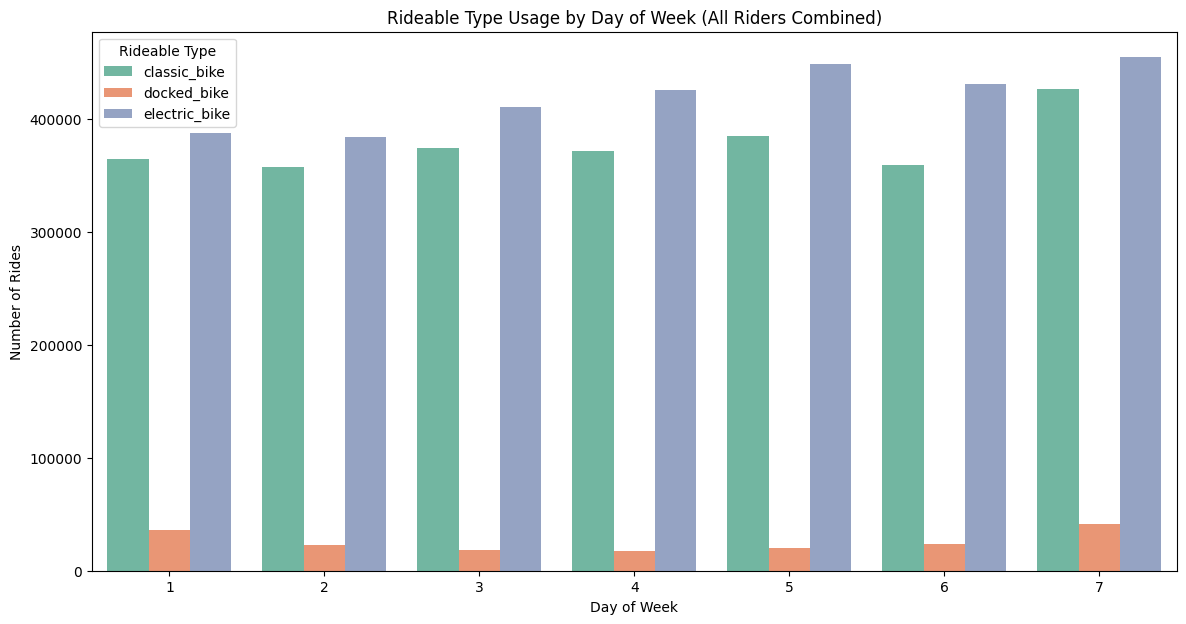

/tmp/ipython-input-1049268066.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.catplot(


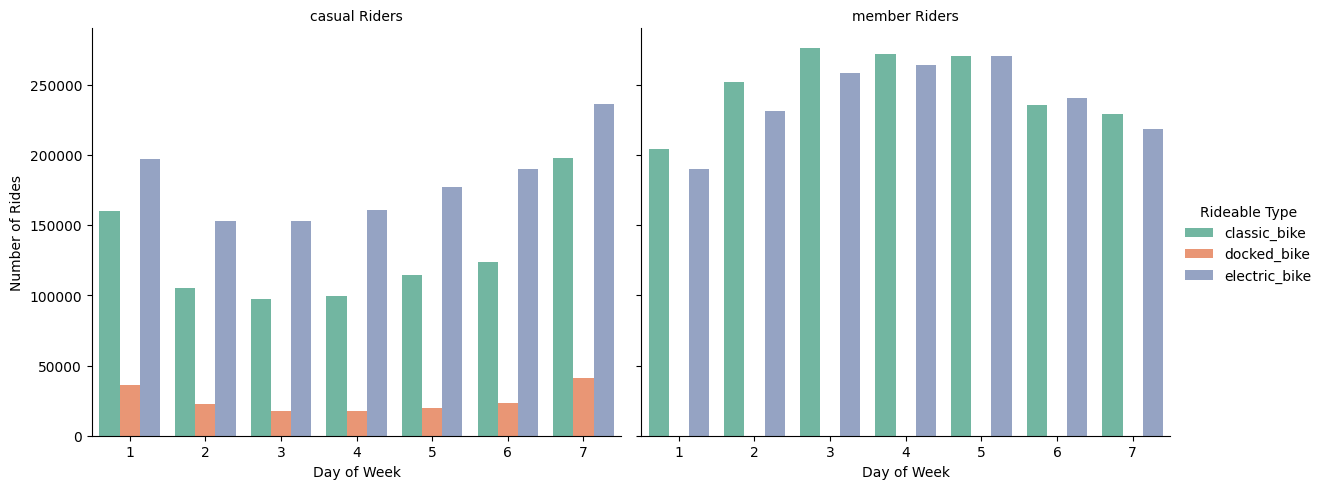

In [ ]:
# Prepare data: count rides by member_casual, Start_day_of_the_week, rideable_type
usage_counts = df.groupby(['member_casual', 'Start_day_of_the_week', 'rideable_type']).size().reset_index(name='ride_count')
print(usage_counts)

# Plot grouped bar chart
plt.figure(figsize=(14, 7))
sns.barplot(data=usage_counts, x='Start_day_of_the_week', y='ride_count', hue='rideable_type', ci=None, palette='Set2', estimator=sum)
plt.title('Rideable Type Usage by Day of Week (All Riders Combined)')
plt.xlabel('Day of Week')
plt.ylabel('Number of Rides')
plt.legend(title='Rideable Type')
plt.show()

# Plot interaction plots separately by member_casual
g = sns.catplot(
    data=usage_counts, kind='bar',
    x='Start_day_of_the_week', y='ride_count',
    hue='rideable_type', col='member_casual',
    ci=None, palette='Set2', estimator=sum,
    height=5, aspect=1.2
)
g.set_axis_labels("Day of Week", "Number of Rides")
g.set_titles("{col_name} Riders")
g._legend.set_title('Rideable Type')
plt.show()


### i. Ride time start Density

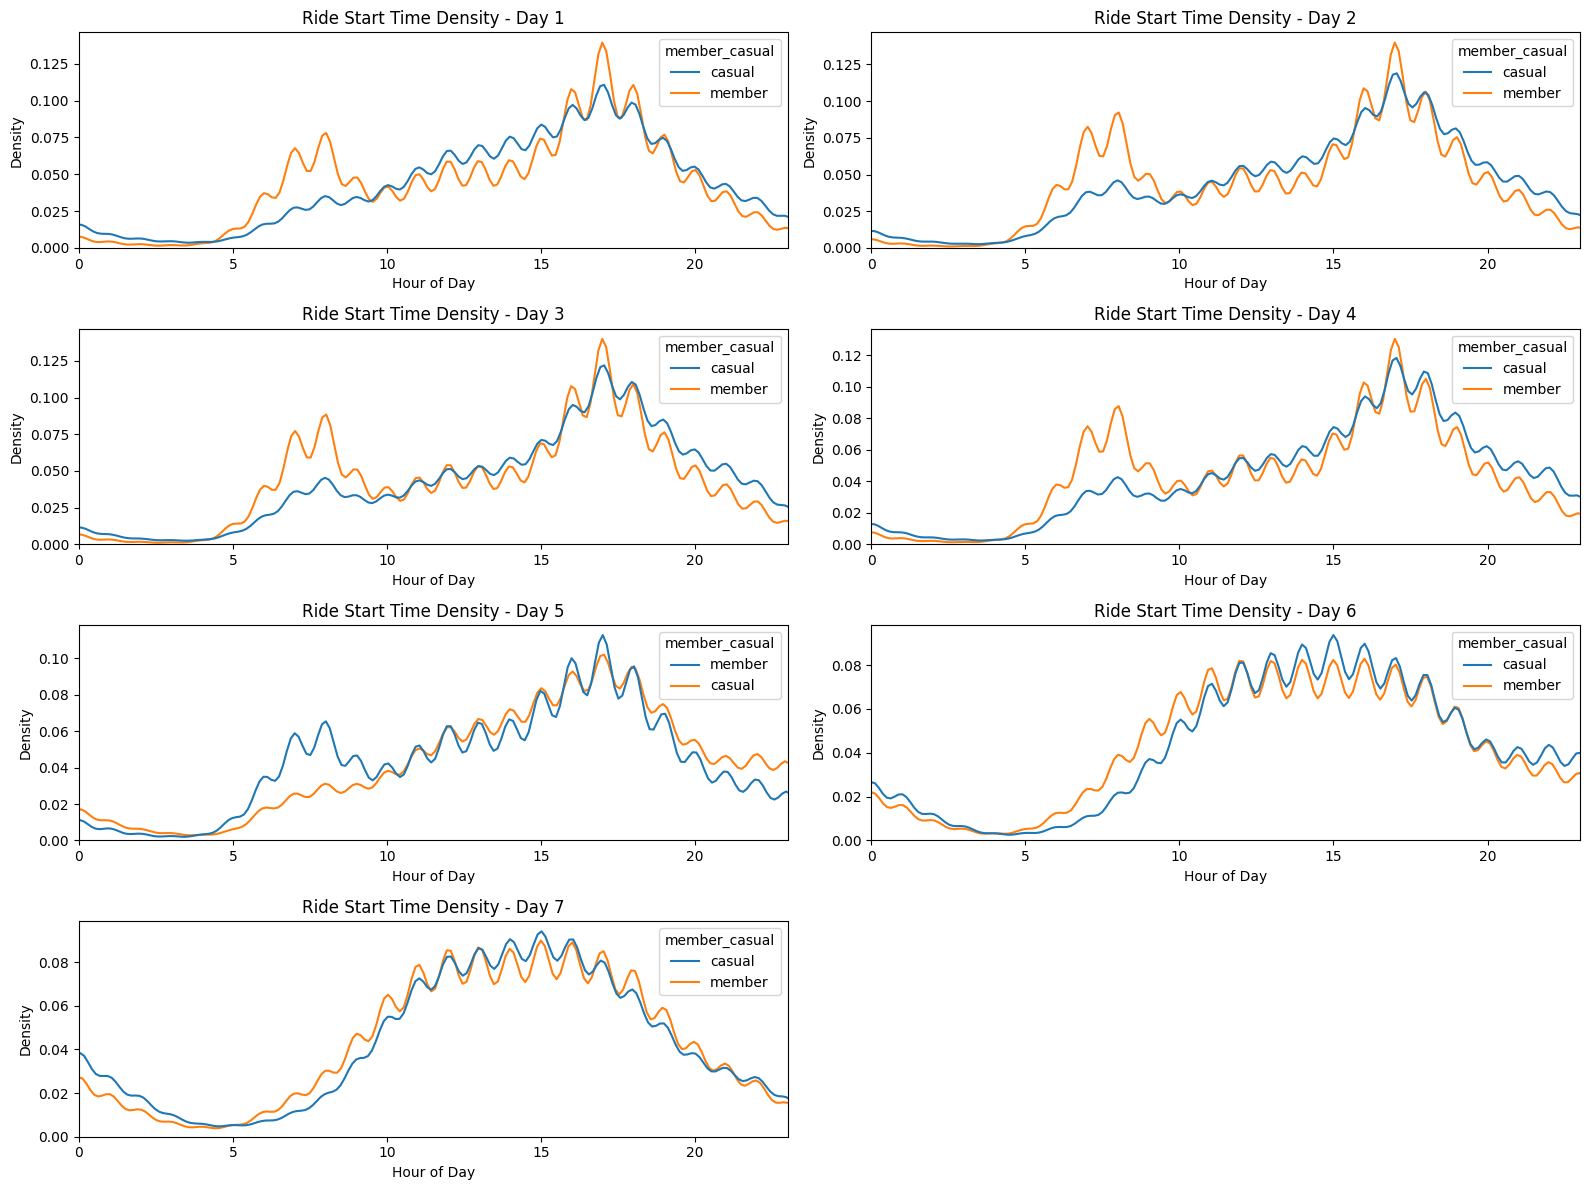

In [ ]:
# Convert started_at to datetime if not already
df['started_at'] = pd.to_datetime(df['started_at'], dayfirst=True)

# Extract day of week number (0=Monday by default in pandas) and hour of day
df['start_day_num'] = df['started_at'].dt.dayofweek + 1  # to make it 1-based index: 1 to 7
df['start_hour'] = df['started_at'].dt.hour

# Sort data by day number
df = df.sort_values('start_day_num')

# Plot density plots of ride start hours by day number and rider type
plt.figure(figsize=(16, 12))
for i in range(1, 8):
    plt.subplot(4, 2, i)
    sns.kdeplot(data=df[df['start_day_num'] == i], x='start_hour', hue='member_casual', common_norm=False)
    plt.title(f'Ride Start Time Density - Day {i}')
    plt.xlabel('Hour of Day')
    plt.xlim(0, 23)
    plt.ylabel('Density')

plt.tight_layout()
plt.show()


### j. Station diversity by rider type

In [ ]:
# Calculate unique start and end stations per rider segment
start_station_diversity = df.groupby('member_casual')['start_station_id'].nunique().reset_index(name='unique_start_stations')
end_station_diversity = df.groupby('member_casual')['end_station_id'].nunique().reset_index(name='unique_end_stations')

# Merge results
station_diversity = pd.merge(start_station_diversity, end_station_diversity, on='member_casual')

print(station_diversity)


  member_casual  unique_start_stations  unique_end_stations
0        casual                   2492                 2501
1        member                   2447                 2435


# Key Observations and Insights

##  Key Observations & Findings
1. Trip Duration and Frequency
- Casual riders take fewer rides but have significantly longer average and median ride lengths per trip (mean ≈ 22 min, median ≈ 13 min) compared to members (mean ≈ 12 min, median ≈ 9 min).

- Members account for more total trips (≈ 59% of rides), with briefer, more routine travel lengths—reflecting commute and daily use behaviors.
- Average ride count per ride_id is essentially 1 for both groups, confirming lack of user-level grouping in raw data.

- Duplicate rides are rare; both segments have negligible repeat ride IDs.

2. Bike Type Usage Patterns
- Members strongly prefer classic bikes (≈ 51% usage vs. 38% for casual), while casual riders disproportionately use electric bikes (54% for casual vs. 49% for members).

- Docked bikes are used mainly by casual riders (8% share) and nearly never by members.

3. Peak Usage Days & Times
- Weekends (Day 7) show peak casual rider activity, outpacing member rides on Sundays.
- Members exhibit consistent ridership across weekdays, peaking modestly on workdays.

- Peak hours: Casual riders concentrate rides during late afternoons and weekends; members ride more during morning and evening commute windows.

4. Station Popularity & Location Demand
- Casual riders favor a mix of numbered/internal stations and some high-traffic public stations (e.g., Streeter Dr & Grand Ave). Internal station codes with high casual counts may indicate issues with data labeling or system exits worth review.

- Members cluster at key networked transit and commuter stations (University Ave & 57th St, Ellis Ave & 60th St), matching routine travel patterns.

- Station diversity: Casual riders use slightly more unique locations, suggesting more exploratory or leisure-based travel patterns than members, whose behavior is more concentrated.

5. Monthly & Geographical Trends
- Seasonal spikes: Casual ridership and ride length soar in spring and summer (May–August), then taper in winter—members remain steadier but also peak with favorable weather.

- Geographic distance: Average trip distances (≈ 2.18 km for casual, 2.12 km for members) are very similar for both segments, but casual rides remain slightly longer on average.

Temporal density plots confirm: Casual ridership peaks afternoons on weekends; members rally mornings/evenings on weekdays.



## Business Takeaways & Recommendations
1. Longer casual rides mean higher propensity for conversion: Focus membership marketing on high-usage, longer-trip casual riders—show them the cost savings of unlimited rides.

2. Leverage electric bike popularity among casuals: Highlight exclusive member benefits for electric bike access, and run seasonal promotions to encourage trial-to-membership upgrades.

3. Target peak usage times and stations: Design campaign messaging and pop-ups for afternoons/weekends at stations with heavy casual draw; incorporate transit-oriented perks for member hotspots.

4. Station & trip insights point to tailored bundles: Develop flexible memberships for leisure/travel-focused casual riders, especially during summer spikes; promote commuter plans at member-dense stations.

5. Clean up station metadata: Review and resolve high-volume internal station codes to ensure true location analysis and improve campaign targeting.

6. Recognize routine vs. exploratory usage: Members' repeat, short-trip patterns suggest satisfaction with core service—casual riders' exploration signals need for educational messaging about full membership value (flexibility, convenience, savings).

7. Seasonal upswing drives opportunity: Time offers and conversion pushes to align with peak casual ridership months for optimal ROI.